In [42]:
import struct
import math
import time
import csv

import casadi as ca
import numpy as np
from matplotlib import pyplot as plt

from scipy.spatial.transform import Rotation as R
from ahrs.common.orientation import acc2q
from ahrs import Quaternion

from scipy.signal import butter, filtfilt, lfilter, lfilter_zi

In [43]:
'''Read raw values'''
from parse import Parser
import mc_common
import random

parser = Parser()
mc_x, mc_y = parser.read_mincopter_log('../../build-generic/mincopter_log.txt')

if False:
    for i,e in enumerate(mc_y.keys()):
        print(f'{e}: {len(mc_y[e])}')

Text(0.5, 1.0, 'Z-pos')

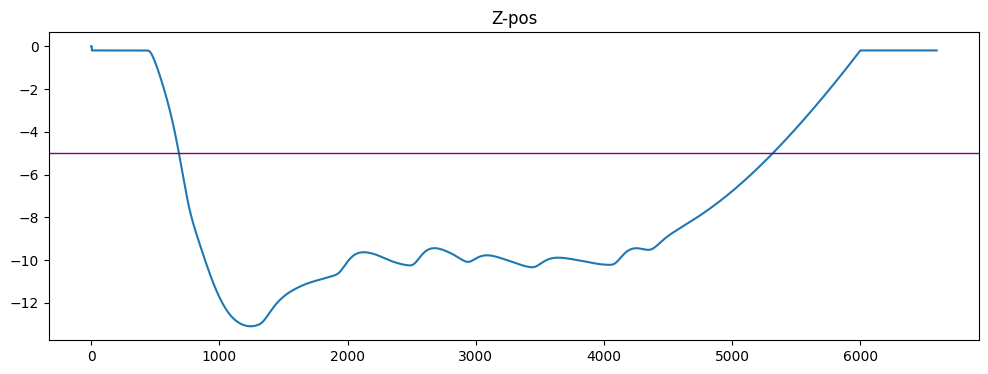

In [44]:
fig, ax = plt.subplots(1,1,figsize=(12,4))
ax.plot(mc_y['pos_z_a'])
ax.axhline(y=-5, color='purple', linewidth=1)
ax.set_title('Z-pos')

## Accelerometer Variances (at hover)

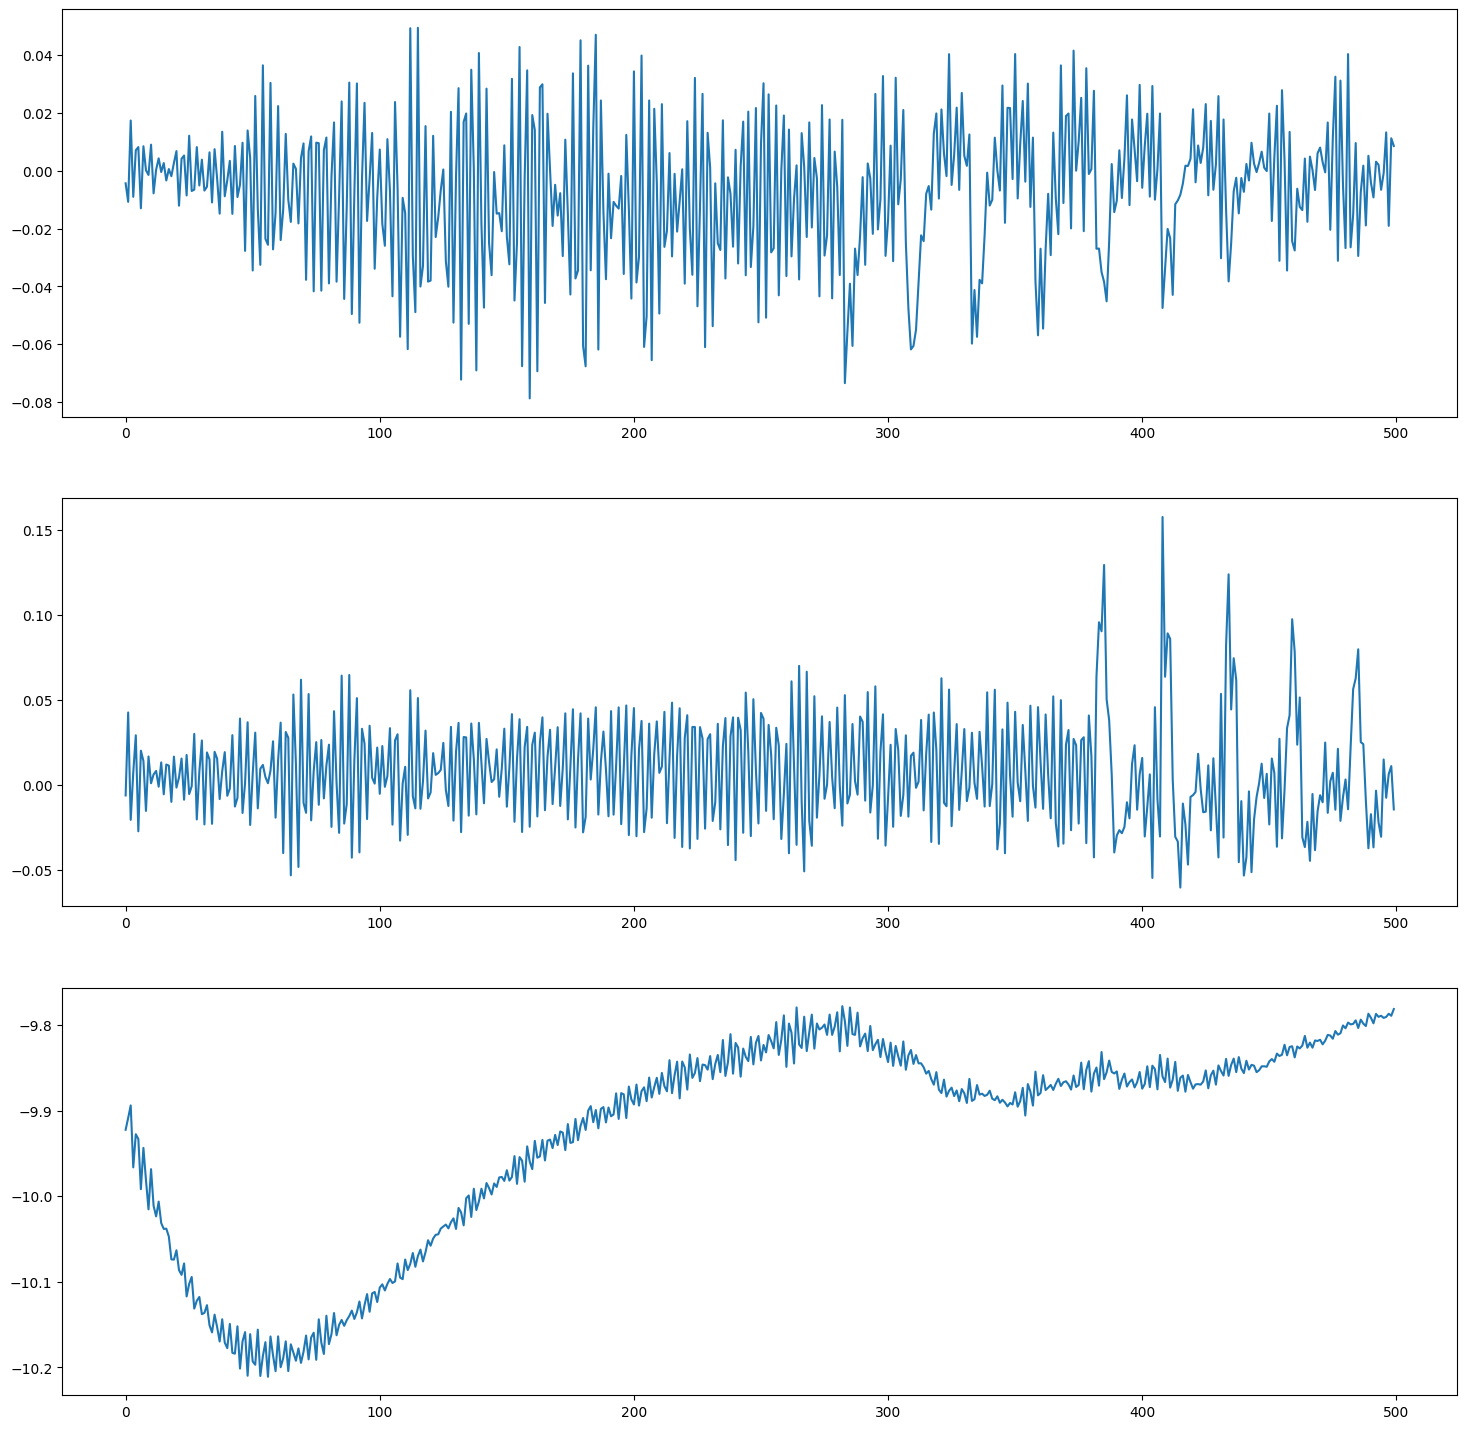

In [45]:
xmin = 3500
xmax = 4000
fig, ax = plt.subplots(3,1,figsize=(18,18))
ax[0].plot(mc_y['accel_x'][xmin:xmax])
ax[1].plot(mc_y['accel_y'][xmin:xmax])
ax[2].plot(mc_y['accel_z'][xmin:xmax])

In [46]:
from scipy.ndimage import standard_deviation, variance

target = [
    np.array(mc_y['accel_x'][xmin:xmax]),
    np.array(mc_y['accel_y'][xmin:xmax]),
    np.array(mc_y['accel_z'][xmin:xmax])]

accel_stddev = [ standard_deviation(t) for t in target]
accel_variance = [ variance(t) for t in target]
print(accel_stddev)
print(accel_variance)
print([np.average(i) for i in target])

[np.float64(0.025077016058349767), np.float64(0.031174107388129216), np.float64(0.1222580626434826)]
[np.float64(0.000628856734390732), np.float64(0.0009718249714466125), np.float64(0.014947033881337717)]
[np.float64(-0.007499943838571198), np.float64(0.007941628448945266), np.float64(-9.928266345977784)]


## Gyrometer Variances (at hover)

In [38]:
from scipy.ndimage import standard_deviation, variance

target = [
    np.array(mc_y['gyro_x'][xmin:xmax]),
    np.array(mc_y['gyro_y'][xmin:xmax]),
    np.array(mc_y['gyro_z'][xmin:xmax])]

accel_stddev = [ standard_deviation(t) for t in target]
accel_variance = [ variance(t) for t in target]
print(accel_stddev)
print(accel_variance)

[np.float64(0.001831761939806953), np.float64(0.0027534925322894163), np.float64(0.004545235426558022)]
[np.float64(3.355351804125332e-06), np.float64(7.581721125373582e-06), np.float64(2.065916508283809e-05)]


## Accelerometer Fusion
During the accelerometer fusion step, we are assuming that the current accelerometer reading can point us downward towards the direction of gravity and hence can provide estimates of the roll and pitch. This reading, however, is corrupted by any other acceleration we might have. Here, we try to estimate the variance of the noise in our measurement, if we reject certain readings when we know that we are accelerating.

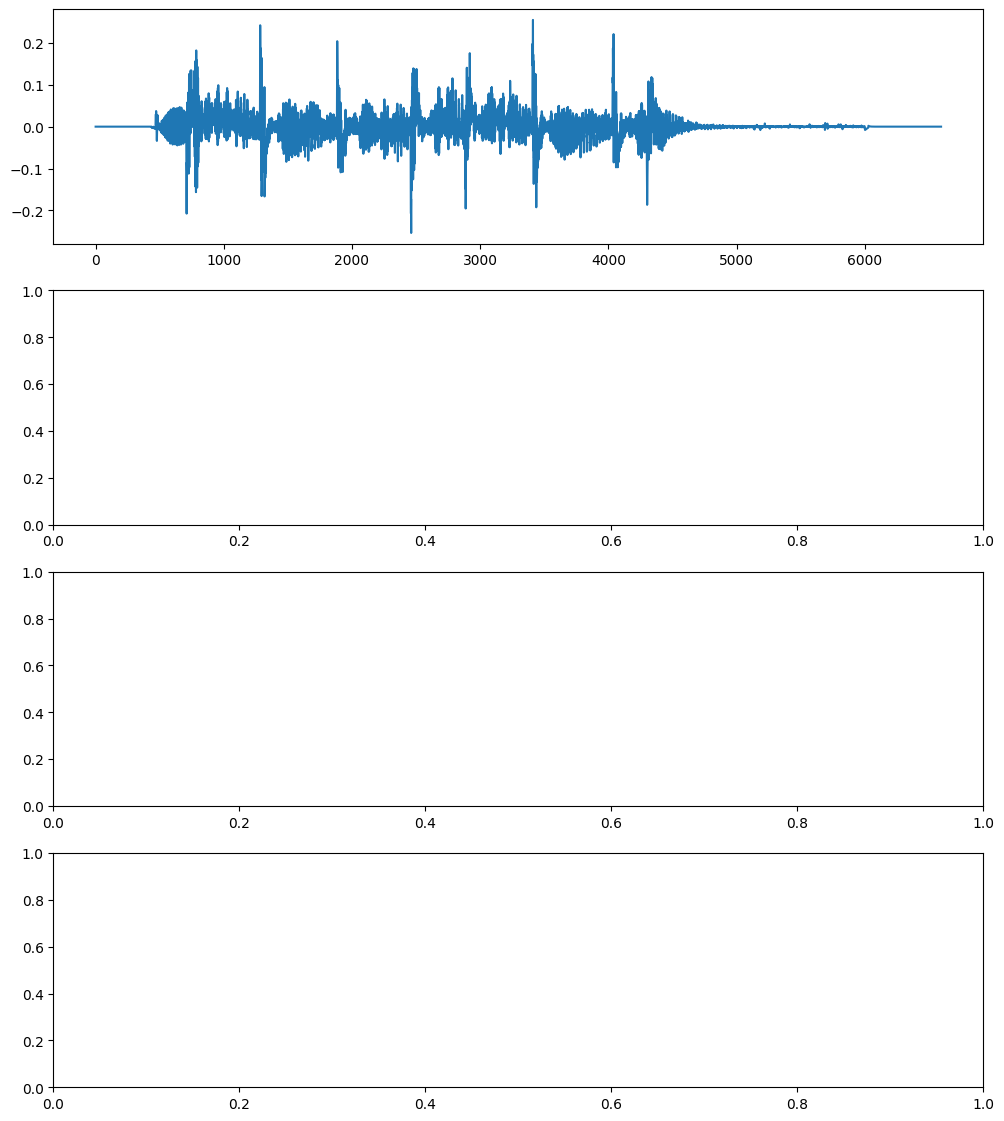

In [51]:
fig, ax = plt.subplots(4,1, figsize=(12,14))

ax[0].plot(mc_y['accel_x'])